# Fitting a Non-Linear Curve
* Dataset: Poly_base.csv
* The Task: Generate synthetic 2D data using a quadratic function plus some random noise (e.g., y=3x^2 + 2x + 1 + noise).
* Objectives:
* Try fitting a standard Linear Regression model and plot it (it will underfit).
* Use PolynomialFeatures(degree=2) to transform the input x.
* Fit a Linear Regression model to the polynomial features and plot the resulting curve against the scatter plot of the data.

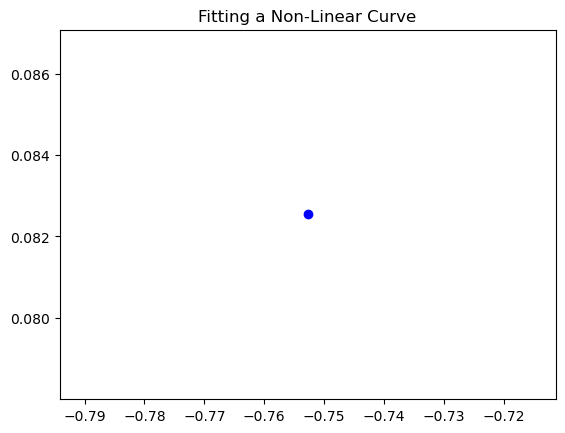

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

df_original = pd.read_csv('Poly_base.csv')
np.random.seed(42)
num_samples = len(df_original) if len(df_original) > 0 else 100
x = np.random.uniform(-3, 3, size=(num_samples, 1))
noise = np.random.normal(loc=0.0, scale=1.0, size=x.shape)
y = 3 * x**2 + 2 * x + 1 + noise
df = pd.DataFrame({'x': x.flatten(), 'y': y.flatten()})
df.to_csv('synthetic_quadratic_data.csv', index=False)
df

Linear_model = LinearRegression()
Linear_model.fit(x, y)
y_predict = Linear_model.predict(x)

poly_feature = PolynomialFeatures(degree=2)
x_poly = poly_feature.fit_transform(x)

lr_poly_model = LinearRegression()
lr_poly_model.fit(x_poly, y)

x_smooth = np.linspace(x.min(), x.max(), 500).reshape(-1, 1)
x_smooth_poly = poly_feature.transform(x_smooth)
y_pred_poly = lr_poly_model.predict(x_smooth_poly)

plt.scatter(x, y, color='blue')
sort_idx = np.argsort(x.flatten())
plt.plot(x[sort_idx], y_predict[sort_idx], color='red', linestyle='--')
plt.plot(x_smooth, y_pred_poly, color='green')
plt.title('Fitting a Non-Linear Curve')
plt.show()

# Visualizing the Bias-Variance Tradeoff
* Dataset: Complex_Non_linear_dataset.csv
* The Task: Take a complex, non-linear 1D dataset.
* Objectives:
* Fit polynomial regression models of varying degrees (e.g., 1, 2, 5, 10, and 20).
* For each degree, calculate both the training error and testing error.
* Plot the degrees on the x-axis and the errors on the y-axis. Identify the point where the model stops learning the underlying pattern and starts memorizing the noise (overfitting).

* Dataset: Complex_Non_linear_dataset.csv

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Load dataset
df = pd.read_csv('Complex_Non_linear_dataset.csv')
df.head()

,0
0,[[0.02 ]\n [0.071]\n [0.087]\n [0.118]\n [0.14...


* The Task: Take a complex, non-linear 1D dataset.

In [15]:
cell_value = df.iloc[0, 0]
clean_value = cell_value.replace('[', '').replace(']', '').strip()
numeric_token = [float(token) for token in clean_value.split() if token]

x = np.array(numeric_token).reshape(-1, 1)
np.random.seed(42)
y = np.sin(2 * np.pi * x) + 0.3 * np.random.normal(size=x.shape)

* Fit polynomial regression models of varying degrees (e.g., 1, 2, 5, 10, and 20).

In [27]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=42)

poly = PolynomialFeatures(degree=2)
x_poly_train = poly.fit_transform(x_train)
x_poly_test = poly.transform(x_test)

x_plot = np.linspace(0, 1, 200).reshape(-1, 1)
x_poly_plot = poly.transform(x_plot)

model = LinearRegression()
model.fit(x_poly_train, y_train)

y_train_pred = model.predict(x_poly_train)
y_test_pred = model.predict(x_poly_test)
y_plot_pred = model.predict(x_poly_plot)

* For each degree, calculate both the training error and testing error

In [26]:
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print(f"The mean squared error of training : {train_mse :.4f}")
print(f"The mean squared error of testing : {test_mse :.4f}")

The mean squared error of training : 0.2402
The mean squared error of testing : 0.2202


### Graph 

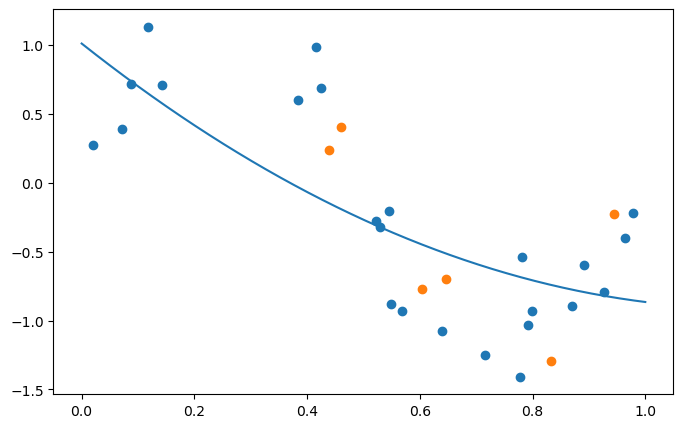

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x_train, y_train)
ax.scatter(x_test, y_test)
ax.plot(x_plot, y_plot_pred)
plt.show()